IPL Team Analysis

Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#interactive visualization
import plotly.express as px

# Display settings
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv(
    r"C:\Users\hp\OneDrive\Desktop\tdp\IPL.csv",
    low_memory=False
)

In [5]:
print(df.shape)

(283678, 65)


In [6]:
print(df.columns)

Index(['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings',
       'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter',
       'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball',
       'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary',
       'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind',
       'player_out', 'fielders', 'runs_target', 'review_batter',
       'team_reviewed', 'review_decision', 'umpire', 'umpires_call',
       'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner',
       'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season',
       'gender', 'team_type', 'superover_winner', 'result_type', 'method',
       'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number',
       'team_runs', 'team_balls', 'team_wicket', 'new_batter',
       'power_surge_start', 'batter_runs', 'batter_balls', 'bowler_wicket',
       'batting_partners', 'next_batter', 'striker_out'],


In [7]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 283678 entries, 0 to 283677
Data columns (total 65 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         283678 non-null  int64  
 1   match_id           283678 non-null  int64  
 2   date               283678 non-null  str    
 3   match_type         283678 non-null  str    
 4   event_name         283678 non-null  str    
 5   innings            283678 non-null  int64  
 6   batting_team       283678 non-null  str    
 7   bowling_team       283678 non-null  str    
 8   over               283678 non-null  int64  
 9   ball               283678 non-null  int64  
 10  ball_no            283678 non-null  float64
 11  batter             283678 non-null  str    
 12  bat_pos            283678 non-null  int64  
 13  runs_batter        283678 non-null  int64  
 14  balls_faced        283678 non-null  int64  
 15  bowler             283678 non-null  str    
 16  valid_ball   

In [8]:
# Missing values
df.isnull().sum()

Unnamed: 0               0
match_id                 0
date                     0
match_type               0
event_name               0
                     ...  
batter_balls             0
bowler_wicket            0
batting_partners         0
next_batter         270085
striker_out              0
Length: 65, dtype: int64

Checking duplicate rows

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


Converting date column into proper datetime format

In [10]:
df['date'] = pd.to_datetime(df['date'])

In [11]:
# Fill string columns
object_cols = df.select_dtypes(include='object').columns
df[object_cols] = df[object_cols].fillna('Not Available')

# Fill numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

In [12]:
print("Total Matches:", df['match_id'].nunique())

Total Matches: 1193


In [13]:
print("Total Teams:", df['batting_team'].nunique())

Total Teams: 19


In [14]:
print(df['batting_team'].unique())

<StringArray>
[      'Kolkata Knight Riders', 'Royal Challengers Bangalore',
         'Chennai Super Kings',             'Kings XI Punjab',
            'Rajasthan Royals',            'Delhi Daredevils',
              'Mumbai Indians',             'Deccan Chargers',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',     'Rising Pune Supergiants',
               'Gujarat Lions',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
        'Lucknow Super Giants',              'Gujarat Titans',
 'Royal Challengers Bengaluru']
Length: 19, dtype: str


In [15]:
print(sorted(df['season'].unique()))

['2007/08', '2009', '2009/10', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020/21', '2021', '2022', '2023', '2024', '2025', '2026']


Matches Played Per Season

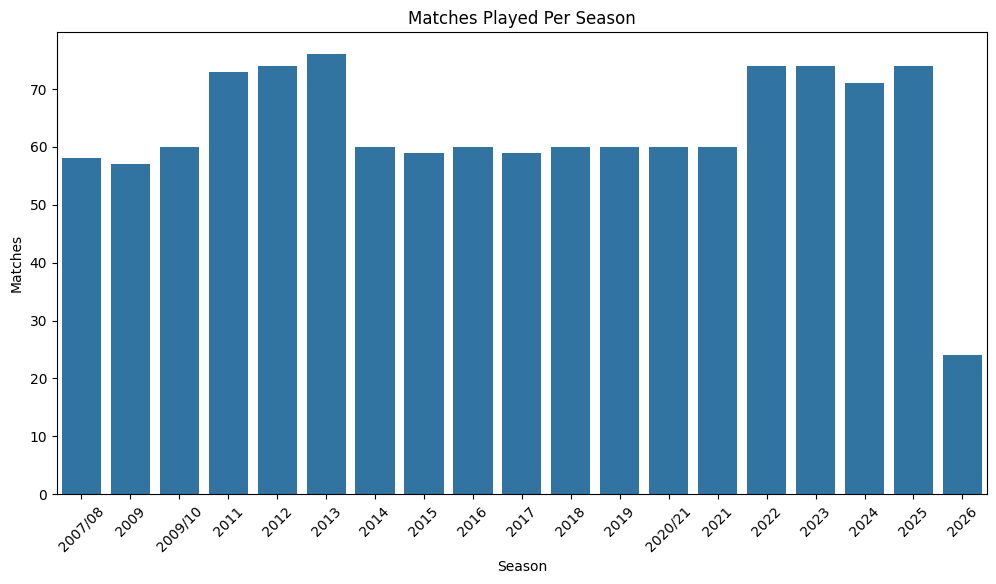

In [16]:
matches_per_season = df.groupby('season')['match_id'].nunique()

plt.figure(figsize=(12,6))
sns.barplot(x=matches_per_season.index, y=matches_per_season.values)

plt.title("Matches Played Per Season")
plt.xlabel("Season")
plt.ylabel("Matches")

plt.xticks(rotation=45)
plt.show()

Top Run Scorers

In [17]:
top_batsmen = df.groupby('batter')['runs_batter'].sum()

top_batsmen = top_batsmen.sort_values(ascending=False).head(10)

print(top_batsmen)

batter
V Kohli           8899
RG Sharma         7185
S Dhawan          6769
DA Warner         6567
SK Raina          5536
MS Dhoni          5439
KL Rahul          5346
AM Rahane         5184
AB de Villiers    5181
CH Gayle          4997
Name: runs_batter, dtype: int64


Visualization of Top Batsmen

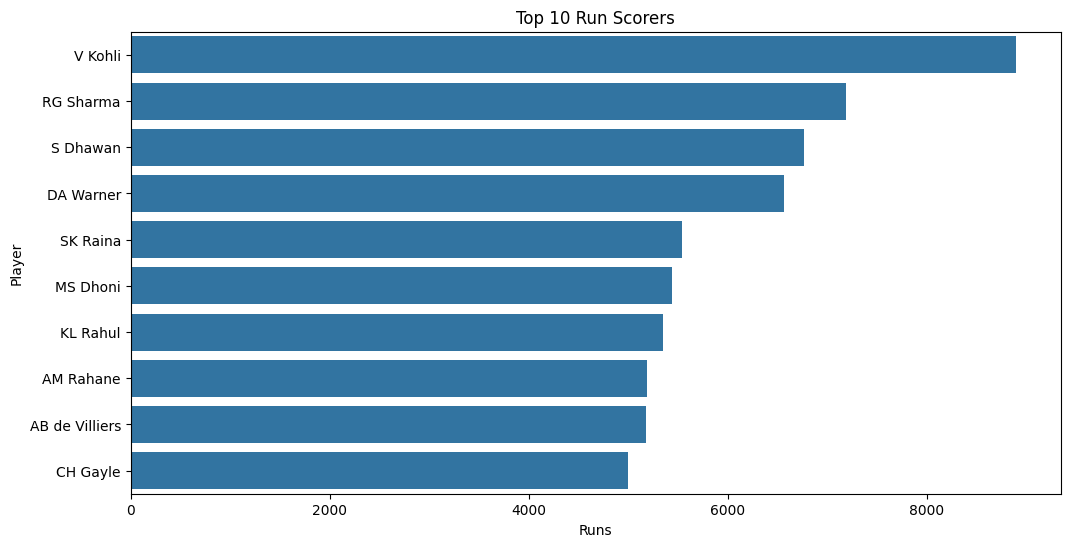

In [18]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_batsmen.values,
    y=top_batsmen.index
)

plt.title("Top 10 Run Scorers")
plt.xlabel("Runs")
plt.ylabel("Player")

plt.show()

Top Wicket Takers

In [19]:
wickets = df[df['wicket_kind'] != 'Not Available']

top_bowlers = wickets.groupby('bowler')['player_out'].count()

top_bowlers = top_bowlers.sort_values(ascending=False).head(10)

print(top_bowlers)

bowler
YS Chahal     233
B Kumar       220
SP Narine     215
DJ Bravo      207
R Ashwin      205
JJ Bumrah     204
PP Chawla     201
SL Malinga    188
A Mishra      183
RA Jadeja     182
Name: player_out, dtype: int64


Visualization 


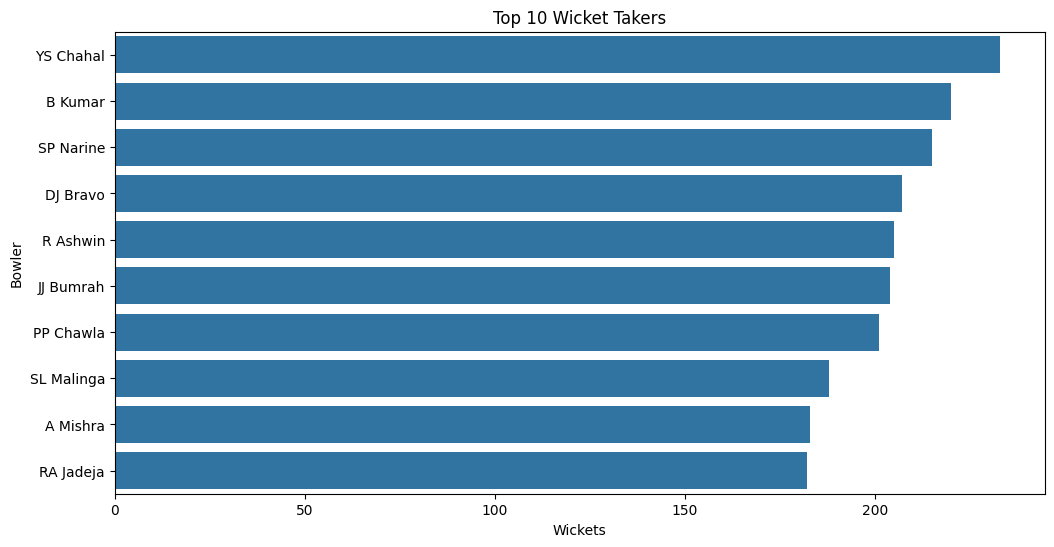

In [20]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_bowlers.values,
    y=top_bowlers.index
)

plt.title("Top 10 Wicket Takers")
plt.xlabel("Wickets")
plt.ylabel("Bowler")

plt.show()

Toss Decision Analysis

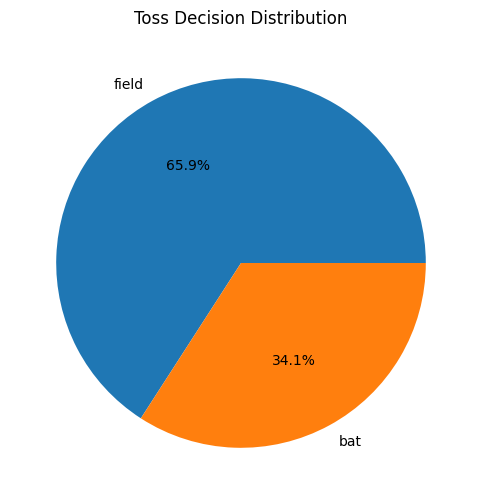

In [21]:
toss_decision = df[['match_id', 'toss_decision']].drop_duplicates()

toss_decision['toss_decision'].value_counts().plot.pie(
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Toss Decision Distribution")
plt.ylabel("")
plt.show()

Top IPL Venues

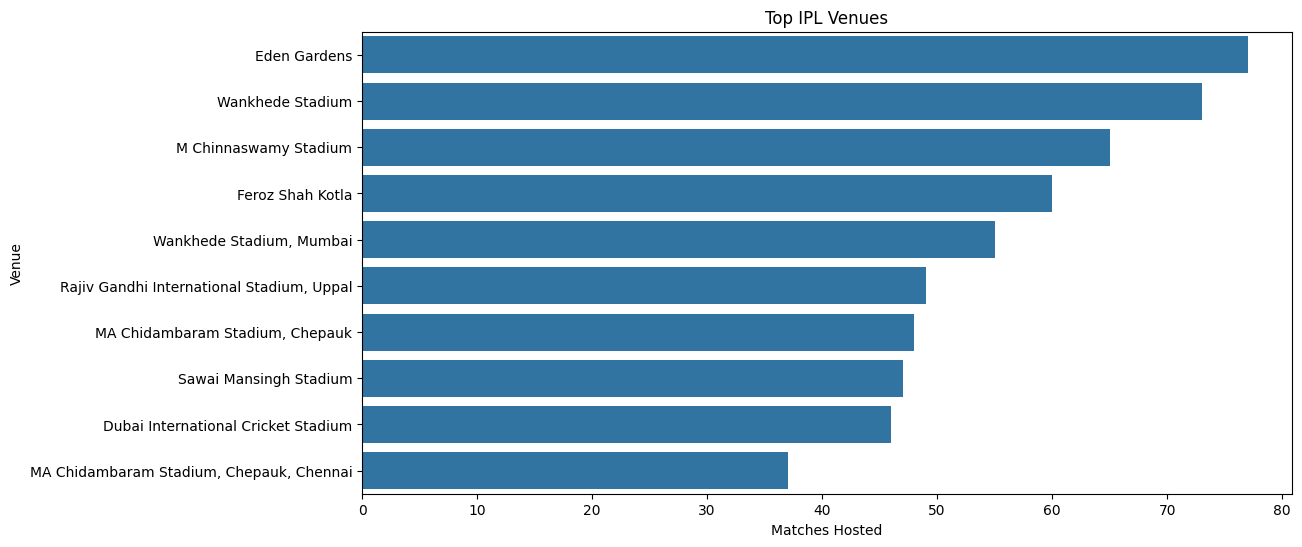

In [22]:
venues = df[['match_id', 'venue']].drop_duplicates()

top_venues = venues['venue'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_venues.values,
    y=top_venues.index
)

plt.title("Top IPL Venues")
plt.xlabel("Matches Hosted")
plt.ylabel("Venue")

plt.show()

Runs by Overs

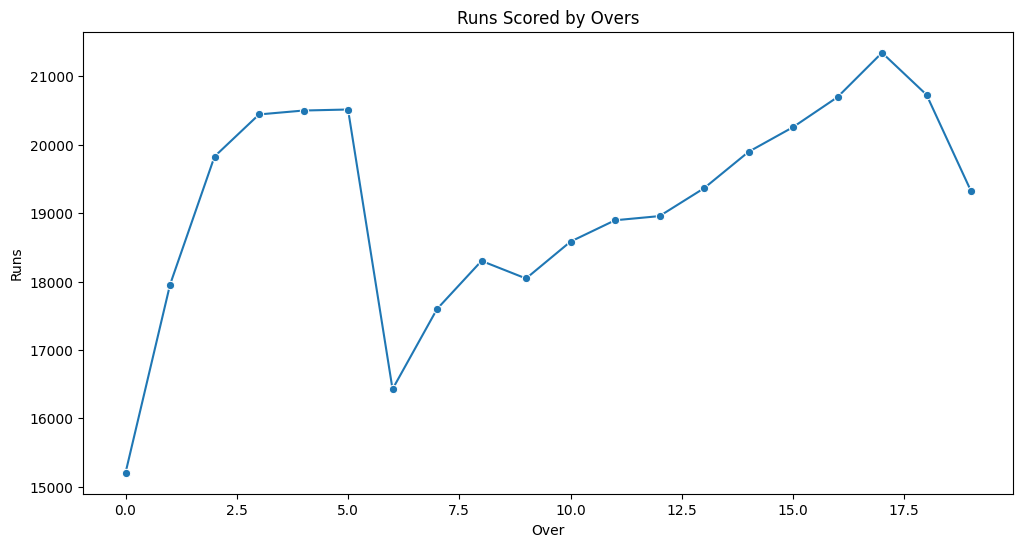

In [23]:
over_runs = df.groupby('over')['runs_total'].sum()

plt.figure(figsize=(12,6))

sns.lineplot(
    x=over_runs.index,
    y=over_runs.values,
    marker='o'
)

plt.title("Runs Scored by Overs")
plt.xlabel("Over")
plt.ylabel("Runs")

plt.show()

Powerplay vs Death Overs

In [24]:
powerplay = df[df['over'] <= 5]

death_overs = df[df['over'] >= 15]

powerplay_runs = powerplay['runs_total'].sum()

death_runs = death_overs['runs_total'].sum()

print("Powerplay Runs:", powerplay_runs)
print("Death Over Runs:", death_runs)

Powerplay Runs: 114441
Death Over Runs: 102347


Pie Chart Analysis

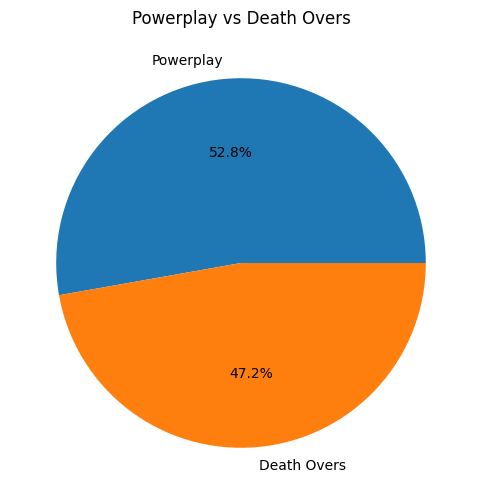

In [25]:
plt.figure(figsize=(6,6))

plt.pie(
    [powerplay_runs, death_runs],
    labels=['Powerplay', 'Death Overs'],
    autopct='%1.1f%%'
)

plt.title("Powerplay vs Death Overs")
plt.show()

Orange Cap Analysis

In [26]:
orange_cap = df.groupby(
    ['season', 'batter']
)['runs_batter'].sum().reset_index()

orange_cap = orange_cap.sort_values(
    ['season', 'runs_batter'],
    ascending=[True, False]
)

orange_cap = orange_cap.groupby('season').head(1)

print(orange_cap)

       season           batter  runs_batter
115   2007/08         SE Marsh          616
229      2009        ML Hayden          572
446   2009/10     SR Tendulkar          618
502      2011         CH Gayle          608
684      2012         CH Gayle          733
910      2013       MEK Hussey          733
1088     2014       RV Uthappa          660
1148     2015        DA Warner          562
1383     2016          V Kohli          973
1422     2017        DA Warner          641
1594     2018    KS Williamson          735
1694     2019        DA Warner          692
1866  2020/21         KL Rahul          676
2051     2021       RD Gaikwad          635
2144     2022       JC Buttler          863
2423     2023     Shubman Gill          890
2606     2024          V Kohli          741
2640     2025  B Sai Sudharsan          759
2896     2026          V Kohli          228


Purple Cap Analysis

In [27]:
purple_cap = wickets.groupby(
    ['season', 'bowler']
)['player_out'].count().reset_index()

purple_cap = purple_cap.sort_values(
    ['season', 'player_out'],
    ascending=[True, False]
)

purple_cap = purple_cap.groupby('season').head(1)

print(purple_cap)

       season             bowler  player_out
77    2007/08      Sohail Tanvir          24
157      2009           RP Singh          26
248   2009/10            PP Ojha          22
375      2011         SL Malinga          30
447      2012           M Morkel          30
519      2013           DJ Bravo          34
650      2014          MM Sharma          26
708      2015           DJ Bravo          28
791      2016            B Kumar          24
879      2017            B Kumar          28
962      2018             AJ Tye          28
1077     2019           K Rabada          29
1161  2020/21           K Rabada          32
1232     2021           HV Patel          35
1402     2022          YS Chahal          29
1469     2023          MM Sharma          31
1542     2024           HV Patel          30
1673     2025  M Prasidh Krishna          26
1769     2026  M Prasidh Krishna          11


Strike Rate Analysis

In [28]:
strike_rate = df.groupby('batter').agg({
    'runs_batter':'sum',
    'balls_faced':'sum'
})

strike_rate['SR'] = (
    strike_rate['runs_batter'] /
    strike_rate['balls_faced']
) * 100

strike_rate = strike_rate[
    strike_rate['balls_faced'] > 500
]

strike_rate = strike_rate.sort_values(
    'SR',
    ascending=False
).head(10)

print(strike_rate)

                 runs_batter  balls_faced          SR
batter                                               
TH David                 993          556  178.597122
PD Salt                 1195          683  174.963397
AD Russell              2655         1525  174.098361
TM Head                 1266          753  168.127490
SP Narine               1816         1090  166.605505
Abhishek Sharma         1945         1174  165.672913
H Klaasen               1704         1029  165.597668
N Pooran                2335         1414  165.134371
RM Patidar              1333          824  161.771845
T Stubbs                 820          513  159.844055


Strike Rate Visualization

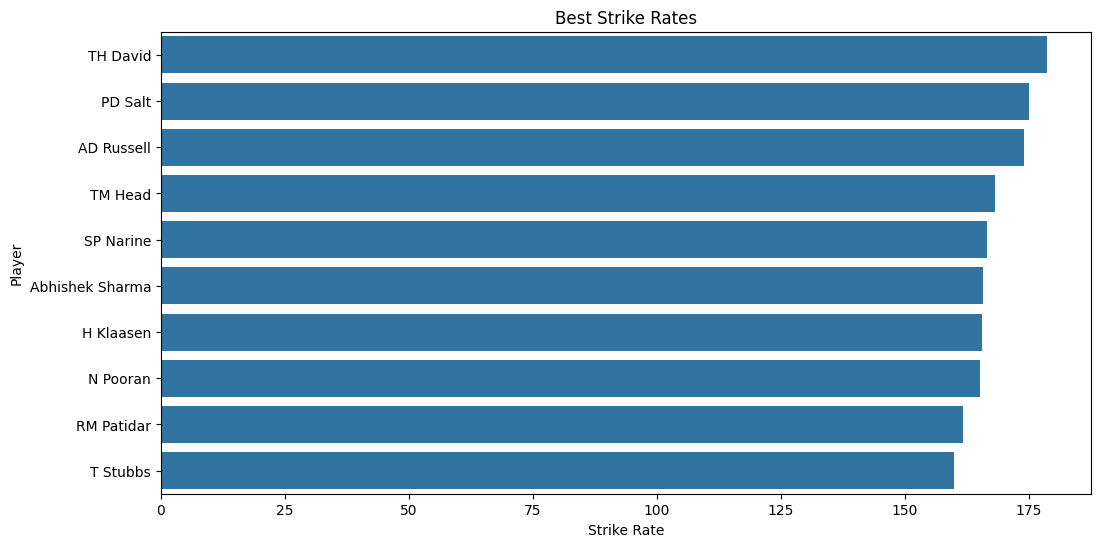

In [29]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=strike_rate['SR'],
    y=strike_rate.index
)

plt.title("Best Strike Rates")
plt.xlabel("Strike Rate")
plt.ylabel("Player")

plt.show()

Economy Rate Analysis

In [30]:
economy = df.groupby('bowler').agg({
    'runs_bowler':'sum',
    'valid_ball':'sum'
})

economy['overs'] = economy['valid_ball'] / 6

economy['economy_rate'] = (
    economy['runs_bowler'] /
    economy['overs']
)

economy = economy[economy['overs'] > 50]

best_economy = economy.sort_values(
    'economy_rate'
).head(10)

print(best_economy)

                  runs_bowler  valid_ball       overs  economy_rate
bowler                                                             
A Kumble                 1058         965  160.833333      6.578238
GD McGrath                357         324   54.000000      6.611111
M Muralitharan           1706        1528  254.666667      6.698953
RE van der Merwe          498         443   73.833333      6.744921
DL Vettori                879         777  129.500000      6.787645
SP Narine                5036        4441  740.166667      6.803873
J Yadav                   445         390   65.000000      6.846154
J Botha                   800         694  115.666667      6.916427
AD Mascarenhas            356         308   51.333333      6.935065
DW Steyn                 2523        2182  363.666667      6.937672


Team-wise Total Runs

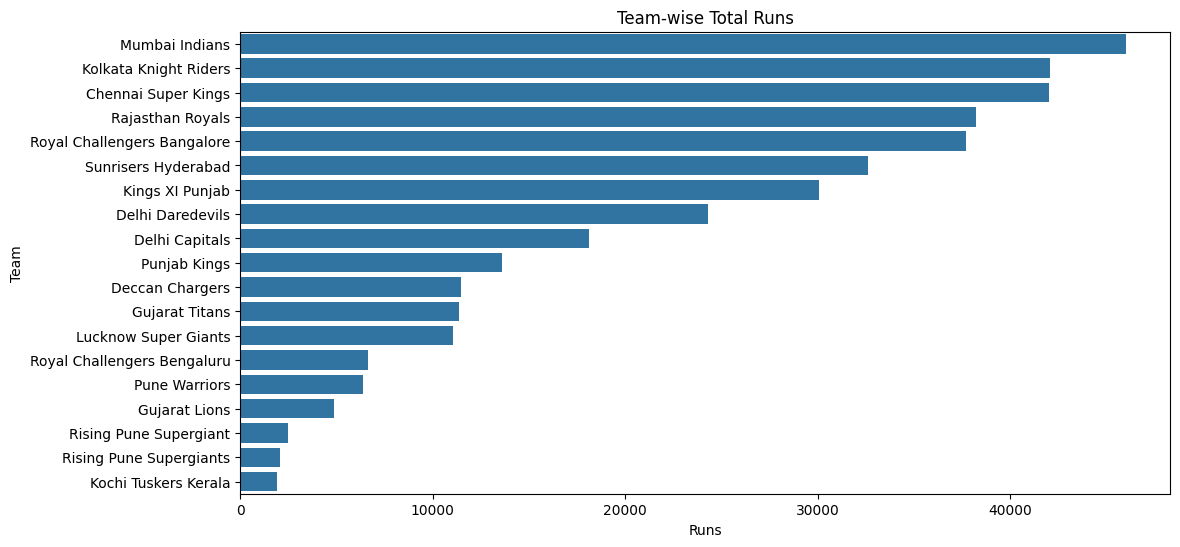

In [31]:
team_runs = df.groupby(
    'batting_team'
)['runs_total'].sum()

team_runs = team_runs.sort_values(
    ascending=False
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=team_runs.values,
    y=team_runs.index
)

plt.title("Team-wise Total Runs")
plt.xlabel("Runs")
plt.ylabel("Team")

plt.show()

In [30]:
individual_scores = df.groupby(
    ['match_id', 'batter']
)['runs_batter'].sum().reset_index()

highest_scores = individual_scores.sort_values(
    'runs_batter',
    ascending=False
).head(10)

print(highest_scores)

       match_id           batter  runs_batter
5302     598027         CH Gayle          175
2        335982      BB McCullum          158
16934   1473464  Abhishek Sharma          141
14108   1304112        Q de Kock          140
7528     829795   AB de Villiers          133
11583   1216510         KL Rahul          132
8359     980987   AB de Villiers          129
15383   1370352     Shubman Gill          129
4687     548372         CH Gayle          128
10149   1136602          RR Pant          128


Correlation Heatmap

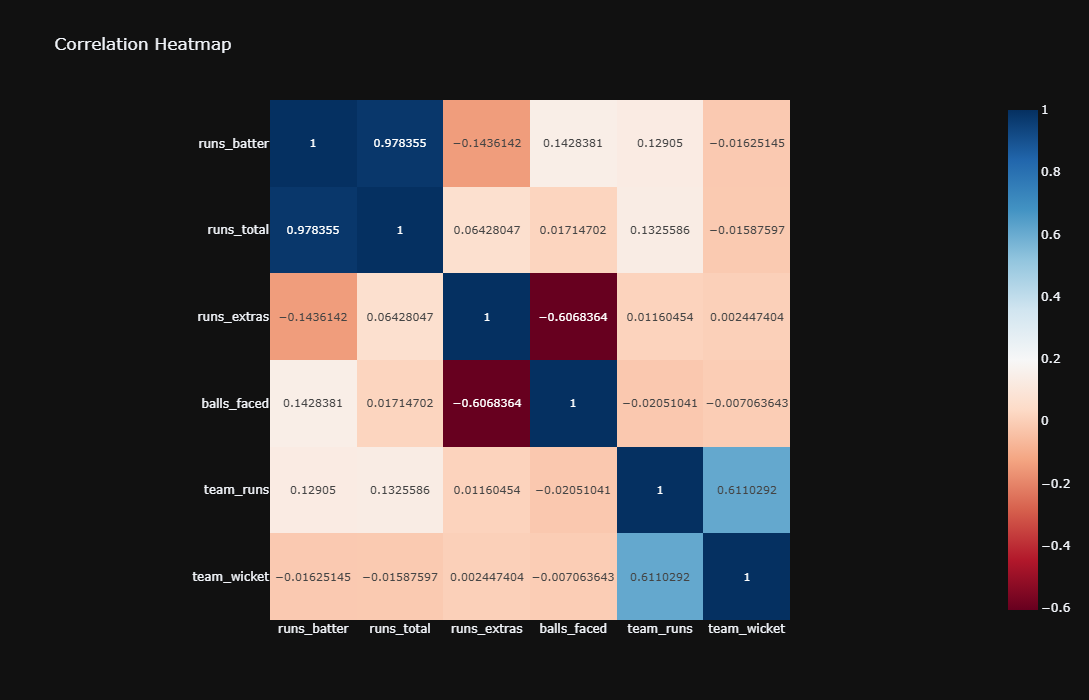

In [31]:
numeric_cols = [
    'runs_batter',
    'runs_total',
    'runs_extras',
    'balls_faced',
    'team_runs',
    'team_wicket'
]

corr = df[numeric_cols].corr()

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale='RdBu',
    title='Correlation Heatmap'
)

fig.update_layout(
    template='plotly_dark',
    height=700
)

fig.show()

Plotly Chart

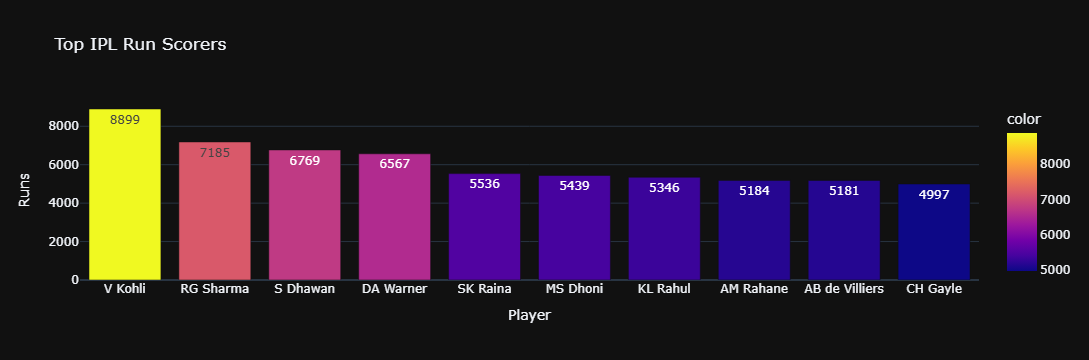

In [32]:
fig = px.bar(
    top_batsmen,
    x=top_batsmen.index,
    y=top_batsmen.values,
    color=top_batsmen.values,
    labels={'x':'Player', 'y':'Runs'},
    title='Top IPL Run Scorers',
    text=top_batsmen.values
)

fig.update_layout(template='plotly_dark')

fig.show()

Most Successfull IPL Teams

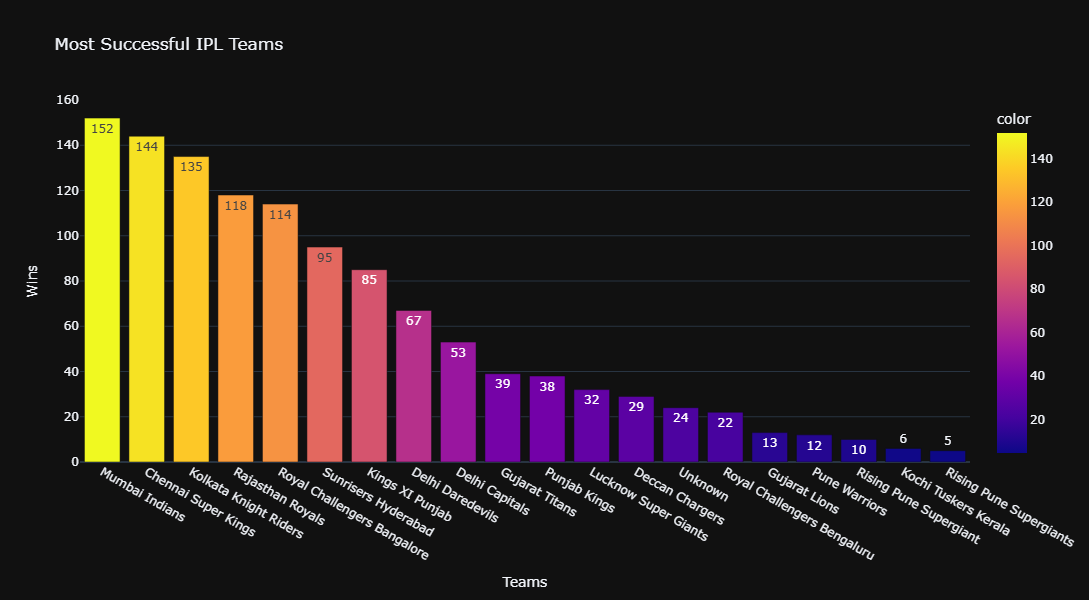

In [33]:
team_wins = df[['match_id', 'match_won_by']].drop_duplicates()

team_wins = team_wins['match_won_by'].value_counts()

fig = px.bar(
    x=team_wins.index,
    y=team_wins.values,
    color=team_wins.values,
    text=team_wins.values,
    title='Most Successful IPL Teams'
)

fig.update_layout(
    template='plotly_dark',
    xaxis_title='Teams',
    yaxis_title='Wins',
    height=600
)

fig.show()

Final Insights:
-Mumbai Indians and CSK are among the strongest IPL teams.
-Virat Kohli and Rohit Sharma are leading run scorers.
-Death overs contribute major runs in T20 cricket.
-Toss decisions influence match outcomes.
-Some stadiums are more batting-friendly.
-Strike rate is a key performance metric.